# Real-Time Object Detection + Optical Flow

### YOLO + Lucas–Kanade Optical Flow

This Google Colab notebook combines a pretrained YOLO detector with Lucas–Kanade optical flow, then measures processing FPS, latency, object counts, and motion.

In [1]:
!pip -q install ultralytics opencv-python-headless pandas matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 1.9 MB/s eta 0:00:00


In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


## Upload a short video

For the first run, use a 20–60 second pedestrian or traffic MP4. A MOT17 sequence is a good benchmark-style choice.

In [2]:
from google.colab import files
uploaded = files.upload()
VIDEO_PATH = next(iter(uploaded.keys()))
print('Using:', VIDEO_PATH)


Saving 123232-727221558.mp4 to 123232-727221558.mp4
Using: 123232-727221558.mp4


In [5]:
!pip install -q ultralytics
from ultralytics import YOLO
import cv2, numpy as np, pandas as pd, time

MODEL_NAME = 'yolo26n.pt'
model = YOLO(MODEL_NAME)
print('Loaded:', MODEL_NAME)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 7.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loaded: yolo26n.pt


In [6]:
feature_params = dict(maxCorners=150, qualityLevel=0.3, minDistance=7, blockSize=7)
lk_params = dict(winSize=(15,15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

def optical_flow(frame, old_gray, new_gray, p0):
    if p0 is None or len(p0) == 0:
        p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
        return frame, p0, 0.0
    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, new_gray, p0, None, **lk_params)
    if p1 is None: return frame, None, 0.0
    good_new, good_old = p1[st==1], p0[st==1]
    mags = []
    for new, old in zip(good_new, good_old):
        a,b = new.ravel(); c,d = old.ravel()
        dx,dy = a-c,b-d; mags.append(float(np.hypot(dx,dy)))
        cv2.arrowedLine(frame,(int(c),int(d)),(int(a),int(b)),(0,255,255),1,tipLength=.25)
        cv2.circle(frame,(int(a),int(b)),2,(0,255,0),-1)
    p_new = good_new.reshape(-1,1,2) if len(good_new) else None
    return frame, p_new, (float(np.mean(mags)) if mags else 0.0)


In [7]:
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened(): raise RuntimeError('Could not open video')
fps_in = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)); height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)); MAX_FRAMES = min(n_frames, 900)
OUT_PATH = '/content/yolo_optical_flow_result.mp4'
writer = cv2.VideoWriter(OUT_PATH, cv2.VideoWriter_fourcc(*'mp4v'), fps_in, (width,height))

ret, frame = cap.read()
old_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
timings=[]; motions=[]; counts=[]

for idx in range(MAX_FRAMES):
    start=time.perf_counter()
    results=model.predict(frame, imgsz=640, conf=0.35, verbose=False,
                          device=0 if torch.cuda.is_available() else 'cpu')
    result=results[0]; annotated=frame.copy(); person_count=0
    if result.boxes is not None:
        boxes=result.boxes.xyxy.cpu().numpy(); classes=result.boxes.cls.cpu().numpy().astype(int)
        confs=result.boxes.conf.cpu().numpy()
        for box,cls,conf in zip(boxes,classes,confs):
            if cls != 0: continue
            person_count += 1
            x1,y1,x2,y2=map(int,box)
            cv2.rectangle(annotated,(x1,y1),(x2,y2),(255,0,0),2)
            cv2.putText(annotated,f'person {conf:.2f}',(x1,max(20,y1-8)),cv2.FONT_HERSHEY_SIMPLEX,.55,(255,0,0),2)
    gray=cv2.cvtColor(frame,cv2.COLOR_BGR2GRAY)
    annotated,p0,avg_motion=optical_flow(annotated,old_gray,gray,p0)
    if p0 is None or len(p0)<20: p0=cv2.goodFeaturesToTrack(gray,mask=None,**feature_params)
    elapsed=time.perf_counter()-start
    timings.append(elapsed); motions.append(avg_motion); counts.append(person_count)
    proc_fps=1/elapsed if elapsed else 0
    cv2.putText(annotated,f'Persons: {person_count}',(15,30),cv2.FONT_HERSHEY_SIMPLEX,.8,(255,255,255),2)
    cv2.putText(annotated,f'Proc FPS: {proc_fps:.1f}',(15,60),cv2.FONT_HERSHEY_SIMPLEX,.7,(255,255,255),2)
    cv2.putText(annotated,f'Latency: {elapsed*1000:.1f} ms',(15,90),cv2.FONT_HERSHEY_SIMPLEX,.7,(255,255,255),2)
    cv2.putText(annotated,f'Flow: {avg_motion:.2f} px/frame',(15,120),cv2.FONT_HERSHEY_SIMPLEX,.65,(255,255,255),2)
    writer.write(annotated)
    old_gray=gray.copy()
    ret,frame=cap.read()
    if not ret: break
cap.release(); writer.release()

metrics=pd.DataFrame({'frame':np.arange(len(timings)),
 'latency_ms':np.array(timings)*1000,
 'processing_fps':1/np.maximum(np.array(timings),1e-9),
 'persons':counts,'avg_flow_px_per_frame':motions})
metrics.head()


,frame,latency_ms,processing_fps,persons,avg_flow_px_per_frame
0,0,1965.314113,0.508825,0,0.000000
1,1,25.125747,39.799812,0,1.616443
2,2,23.702417,42.189790,0,2.007148
3,3,24.154691,41.399826,0,3.004322
4,4,21.075933,47.447484,0,2.160300


In [8]:
print(f'Frames processed: {len(metrics):,}')
print(f'Input FPS: {fps_in:.2f}')
print(f'Mean processing FPS: {metrics.processing_fps.mean():.2f}')
print(f'Mean latency: {metrics.latency_ms.mean():.2f} ms/frame')
print(f'Mean detected persons/frame: {metrics.persons.mean():.2f}')
print(f'Mean optical-flow displacement: {metrics.avg_flow_px_per_frame.mean():.2f} px/frame')


Frames processed: 569
Input FPS: 29.97
Mean processing FPS: 41.47
Mean latency: 31.34 ms/frame
Mean detected persons/frame: 4.37
Mean optical-flow displacement: 9.39 px/frame


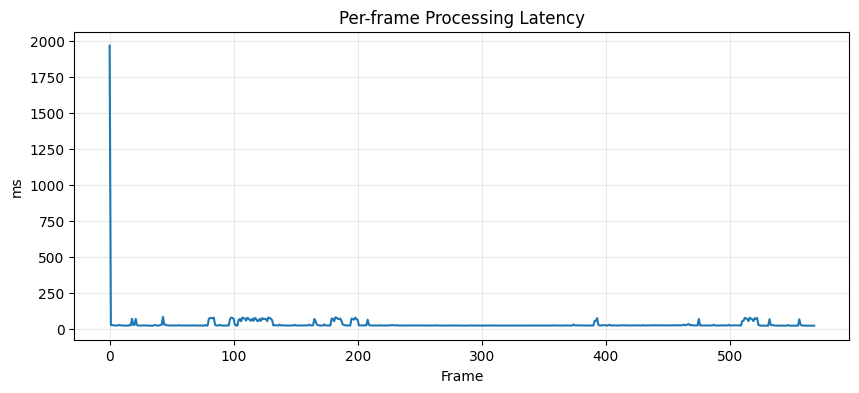

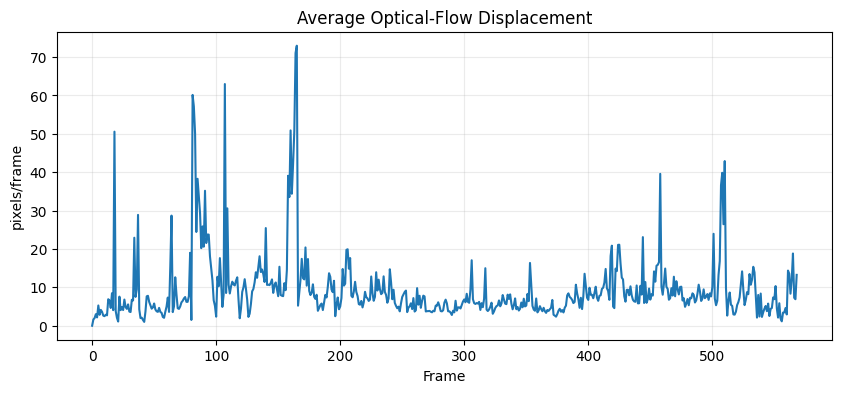

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4)); plt.plot(metrics.frame,metrics.latency_ms); plt.title('Per-frame Processing Latency'); plt.xlabel('Frame'); plt.ylabel('ms'); plt.grid(alpha=.25); plt.show()
plt.figure(figsize=(10,4)); plt.plot(metrics.frame,metrics.avg_flow_px_per_frame); plt.title('Average Optical-Flow Displacement'); plt.xlabel('Frame'); plt.ylabel('pixels/frame'); plt.grid(alpha=.25); plt.show()


In [11]:
from google.colab import files
files.download(OUT_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>